## Problems with training a neural network

* You can face the _vanishing gradients_ or _exploding gradients_ problem. This is when the gradients become smaller or larger as the gradient calculation goes backward through the DNN, which makes it hard to train the first few layers in the model. 
* The amount of data might not be enough to train such a large model.
* Training may be extremely slow. 
* A model with millions of parameters would severely risk overfitting the training set, especially if there are not enough training instances or if they are too noisy.

## The Vanishing/Exploding Gradients Problems

The problem is that with vanishing gradients, the gradients get smaller and smaller as backpropagation progresses backwards towards the first few layers in the model, which makes the weight update for these layers insignificant, leaving them virtually unchanged. On the other hand, with exploding gradients, the first few layers get updates with very large values, making the weights diverge and net reach a good solution. This is most commonly the situation in recurrent neural networks. 

The old initialization scheme used to be choosing random values from the normal distribution with a mean of 0 and a standard deviation of 1. Additionally, the sigmoid activation function was commonly used in the early days of DNN. The problem with this configuration is that the outputs of each layer have more variance than the inputs, meaning that the variance keeps increasing as the information propagates forward in the model. 

This variance continues to increase until the activation function saturates at the top layers. When the activation function saturates, the backpropagation calculates a derivative that is extremely close to 0, which means that virtually no gradient propagates back through the network. 

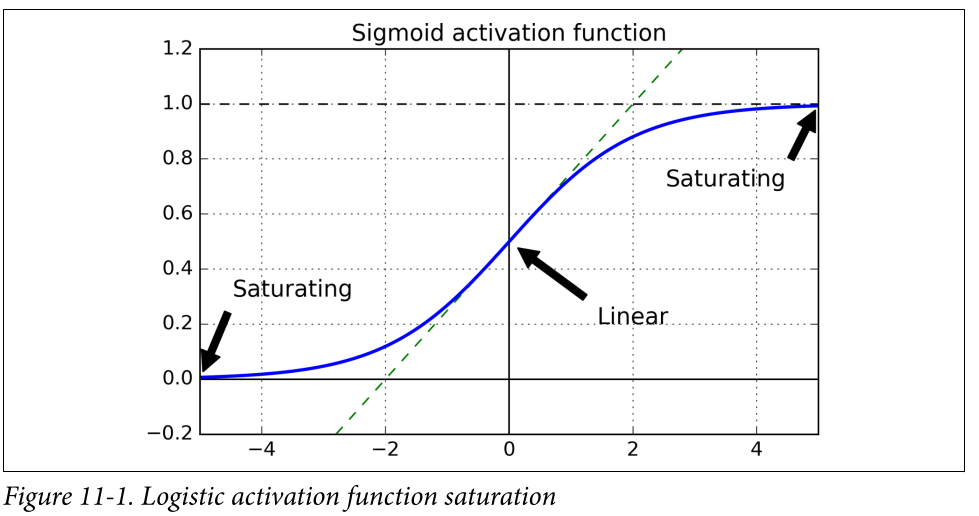

## Glorot and He Initialization

The general idea to combat the exploding/vanishing gradients problem is to make sure that the variance of the input is the same as the variance of the output for layer in both directions (forward and backward). However, this is not possible to achieve unless the number of inputs is equal to the number of outputs in each layer. Fortunately, Glorot and Bengio proposed a good compromise that has proven to work well in practice. The solution is the following:
initialize the layers weights using the following random distributions: 

$fan_{avg} = \frac{(fan_{in} + fan_{out})}{2}$

For the normal distribution initialization, the mean must be 0, and the variance must be:

$\sigma^2 = \frac{1}{fan_{avg}}$

for the uniform distribution between -r and +r, with r:

$r = \sqrt{\frac{3}{fan_{avg}}}$


LeCun initialization is equivalent to Glorot initialization when $fan_{in} = fan_{out}$, it used to substitute $fan_{in}$ in the equation described above, but Glorot proposed using $fan_{avg}$ instead, which lead to much better results. 

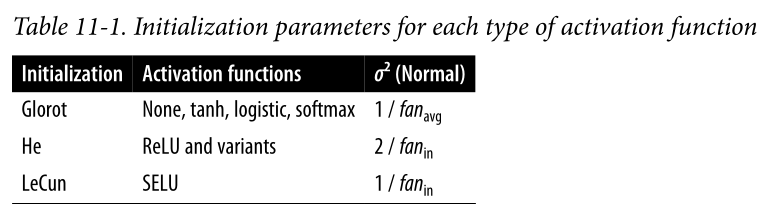

By default, Keras uses the Glorot initialization with a uniform distribution. You can chang this by setting the kernel_initializer parameter as follows:

In [2]:
import tensorflow as tf, keras
keras.layers.Dense(10, activation = 'relu', kernel_initializer='he_normal')

<Dense name=dense_1, built=False>

If you want to use He initialization but use $fan_{avg}$ instead of $fan_{in}$, you can do it as follows:

In [3]:
he_avg_init = keras.initializers.VarianceScaling(scale = 2.0, mode = 'fan_avg', distribution='uniform')
keras.layers.Dense(10, activation = 'sigmoid', kernel_initializer=he_avg_init)

<Dense name=dense_1, built=False>

## Nonsaturating Activation Functions

ReLU is a nonsaturating activation function. However, it suffers from the dead neuron problem, where some neurons (sometimes as much as half of them!) stop outputting anything and just output 0. This happens because the net input into the neuron before the activation function is applied is negative, which means that ReLU outputs a 0. 

To solve this issue, other variants of the ReLU activation function have been proposed. These variants include:

1. Leaky ReLU: if the input is negative, the activation function allows for a value other than zero. Negative values have a slope that is different than the one used for positive values. 
2. Randomized Leaky ReLU: Same as Leaky ReLU, but the slope is set randomly. 
3. Parameterized Leaky Relu: The slope of the negative values is another parameter that can be tweaked using backpropagation. 
4. ELU: The negative part of the function is defined using an exponential function. 

Leaky ReLU:
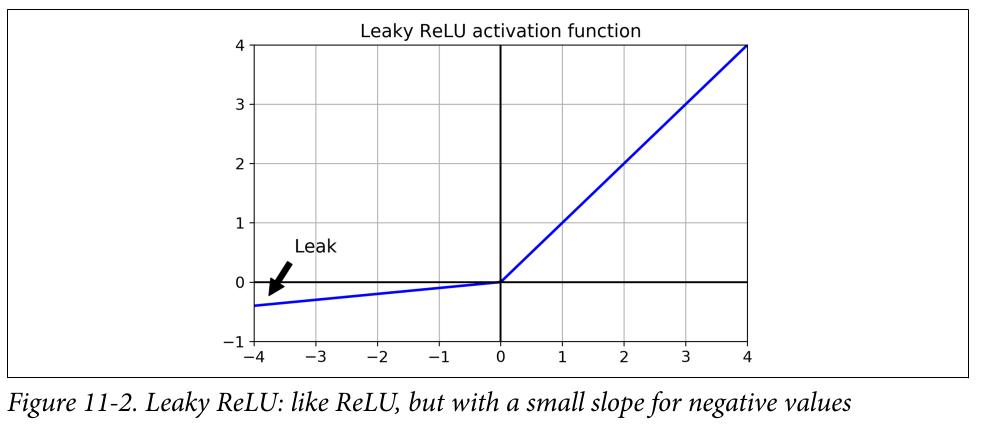

ELU:
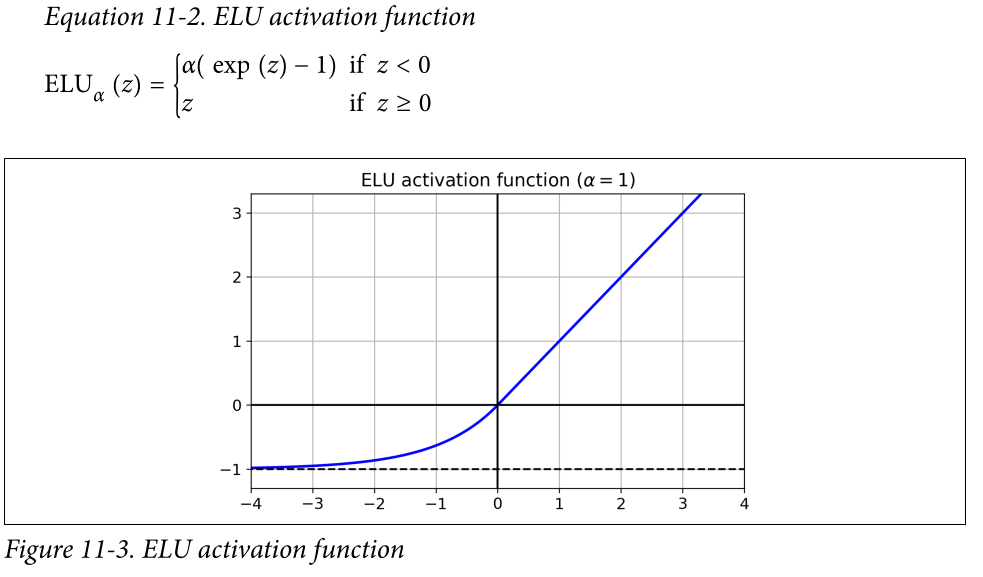

ELU generally performs better than ReLU and its variants, but it is slower to compute. However, it converges quickly during training, which compensates for that slow computation. 

__Note:__ The test time (inference time) on ELU will still be slower than with ReLU and its variants. 

There is another variant to the ELU activation function that is called SELU (Scaled ELU), which is simply a scaled version of ELU. The main benefit to this activation function is that the network will _self-normalize_, which means that the output of each layer will preserve a mean of 0 and a standard deviation of 1 during training; therefore, solving the vanishing/exploding gradients problem. It is worth noting that the are conditions that need to be met in order for self-normalization to occur. These conditions are:

1. The input features must be standardized (mean 0 and standard deviation 1). 
2. Every hidden layer's weights must be initialized with LeCun normal initialization. (Setting kernel_initializer = 'lecun_normal' in keras).
3. The network's architecture must be sequential (no skipping and no recurrent layers). 
4. The paper guarantees self-normalization if all layers are dense, but some researchers have noted that the SELU activation function can improve the performance of convolutional neural networks as well.
 

### Which activation function to use?

In general:
SELU > ELU > Leaky ReLU (and its variants) > ReLU > tanh > logistic sigmoid. 

If the network architecture doesn't guarantee self-normalization, you may want to choose ELU. 

If you want a low runtime latency, you might want to choose a variant of Leaky ReLU. However, since ReLU is the most commonly used activation function by far, many hardware accelerators provide ReLU-specific optimizations, which makes it the best choice if you care about speed. 

In [4]:
#Example using the Leaky Relu activation function
model = keras.models.Sequential([
    keras.layers.Input(shape = (28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(100, kernel_initializer='he_normal'),
    keras.layers.LeakyReLU(alpha = 0.2),
    keras.layers.Dense(10, activation = 'softmax')
])

/home/thoalfeqar/miniconda3/envs/tf/lib/python3.12/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
I0000 00:00:1725199941.467060   10381 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1725199941.508617   10381 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1725199941.508850   10381 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. Se

In [5]:
#Example using SeLU
layer = keras.layers.Dense(10, activation = 'selu', kernel_initializer = 'lecun_normal')

## Batch Normalization

Batch normalization is an operation that can help reduce or eliminate the vanishing/exploding gradients problem in DNN. This is done by zero centring and normalizing the data coming into a layer, and then shifting it and scaling it according to two parameters that can be tweaked during learning. 

__Note:__ You don't need to scale your data using something like a StandardScaler, since Batch Normalization will do that for you if you use it at the beginning of network (it will approximately standardize the data since it only looks at a single batch to calculate its parameters). 

Batch normalization works as follows:

1. $\mu_{B} = \frac{1}{m_{B}}\sum_{i = 1}^{m_{B}}x^{(i)}$

2. $\sigma_{B}^2 = \frac{1}{m_{B}}\sum_{i = 1}^{m_{B}}(x^{(i)} - \mu_{B})^2$

3. $\hat{x}^{(i)} = \frac{x^{(i)} - \mu_{B}}{\sqrt{\sigma_{B}^2 + \epsilon}}$

4. $z^{(i)} = \gamma * \hat{x}^{(i)} + \beta$

* $\mu_{B}$ is the vector of input means over the entire batch B (it contains one mean per input).
* $\sigma_{B}$ is the vector of input standard deviations, also evaluated over the whole mini-batch (it contains one standard deviation per input). 
* $m_{B}$ is the number of instances in the mini-batch. 
* $\hat{x}^{(i)}$ is the vector of zero-centered and normalized inputs for instance i. 
* $\gamma$ is the output scale parameter vector for the layer (it contains one scale parameter per input).
* $\beta$ is the output shift (offset) parameter vector for the layer. (it contains one offset parameter per input). 
*  $\epsilon$ is a tiny number to avoid division by zero. 
* $z^{(i)}$ is the output of the BN operation. 


There is a problem though. What do we do during testing? How are we going to calculate the mean and standard deviation for the input if there is only one instance? (You cannot calculate a mean and standard deviation for a single instance!).

To solve this issue, we could wait until the training finishes, and then pass the entire dataset into the neural network to calculate the "final" values for the mean and standard deviation for each BN layer. However, the approach that is used in practice is to calculate the values of the mean and standard deviation as a moving average during training. This is what keras does by default.

__Note:__ Batch Normalization can also act as a regularizer, which reduces the need to use somethings like dropout or l1 and l2 regularization. 

Batch normalization does, however, add some complexity to the model, which makes it slower. This can be solved by fusing the BN layer with the pervious layer as follows:

If we say that the previous layer computes the output as: $XW+ b$, then the BN layer will compute $\gamma*(XW + b - \mu)/\sigma + \beta$

If we define $W^{'} = \gamma * W/\sigma$ and $b^{'} = \gamma*(b-u)/\sigma + \beta$, the equation becomes: $XW^{'} + b^{'}$.   

We can then use the above final equation to modify the weights of the previous layer, which reduces the computation cost!

__Note:__ TFLite automatically does this. 

In [6]:
model = keras.models.Sequential([
    keras.layers.Input(shape = (28, 28)),
    keras.layers.Flatten(),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(256, activation = 'elu', kernel_initializer = 'he_normal'),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(128, activation = 'elu', kernel_initializer = 'he_normal'),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(10, activation = 'softmax')
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 784)            │         3,136 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 239,818 (936.79 KB)

 Trainable params: 237,482 (927.66 KB)

 Non-trainable params: 2,336 (9.12 KB)

In [7]:
#Taking a look at the Batch Normalization variables
[(var.name, var.trainable) for var in model.layers[1].variables]

[('gamma', True),
 ('beta', True),
 ('moving_mean', False),
 ('moving_variance', False)]

The authors of the BN paper argued that the BN layer should be placed before the activation function. There is some debate about this fact, so experiment with which one works best on your Dataset!

__Note:__ You can remove the bias term from the dense layers since the BN layer has an offset parameter for each input value, which acts as the bias term!

In [8]:
#Batch normalization before the activation function

model = keras.models.Sequential([
    keras.layers.Input(shape = (28, 28)),
    keras.layers.Flatten(),
    keras.layers.BatchNormalization(),
   
    keras.layers.Dense(256, use_bias = False, kernel_initializer = 'he_normal'),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('elu'),
   
    keras.layers.Dense(128, use_bias = False, kernel_initializer = 'he_normal'),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('elu'),
   
    keras.layers.Dense(10, activation = 'softmax')
])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 784)            │         3,136 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       200,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 239,434 (935.29 KB)

 Trainable params: 237,098 (926.16 KB)

 Non-trainable params: 2,336 (9.12 KB)

### Hyperparameters to tune for the BN layer

You can tune the momentum term in the BN layer, which is a term that controls the computation of the moving average during training:

$\hat{v} = \hat{v} * momentum + v * (1-momentum)$ <br>
$\hat{v}$ = the running average. <br>
$v$ = new vector of input means and standard deviations. 
A good value for the momentum is closer to 1. 

For example, 0.9, 0.99, 0.999 (you want more 9s for larger datasets and smaller mini-batches).

Another hyperparameter is the axis, which determines the axis that should be normalized. It defaults to -1, which means that by default it will normalize the last axis (using the means and standard deviations computed across the other axes).

If the input features are of the shape [batch size, features], then the features axis will be normalized across the batch size. 

If the input features are of the shape [batch size, height, width], then the width will be normalized using the columns and batch size. 

In the following example, the channels axis is the one that is being normalized using the values calculated across the other axes (batch size, height, width). 

In [25]:
model = keras.models.Sequential([
    keras.layers.Input(shape = (28, 28, 3)),
    keras.layers.BatchNormalization(),

    keras.layers.Conv2D(32, (3, 3)),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),

    keras.layers.Conv2D(32, (3, 3)),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),

    keras.layers.Flatten(),
    keras.layers.Dense(100),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),

    keras.layers.Dense(100),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),

    keras.layers.Dense(10, activation = 'softmax')
])
model.summary()


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_89          │ (None, 28, 28, 3)      │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 26, 26, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_90          │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_79 (Activation)      │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_91          │ (None, 24, 24, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_80 (Activation)      │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 100)            │     1,843,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_92          │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_81 (Activation)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_93          │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_82 (Activation)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,865,622 (7.12 MB)

 Trainable params: 1,865,088 (7.11 MB)

 Non-trainable params: 534 (2.09 KB)

## Gradient Clipping

Gradient clipping mitigates the exploding gradients problem by limiting the gradient to a specific threshold. This is useful with network where Batch Normalization doesn't work well such as Recurrent Neural Networks RNNs. 

In [26]:
optimizer = keras.optimizers.SGD(clipvalue = 1.0) #setting the clipvalue enables the gradient clipping!

With the settings above, the optimizer will limit the values of the gradient to between -1 and 1. 

__Note:__ Value clipping can change the orientation of the vector. For example, the vector [0.9, 100.0] points in the direction of the second axis; but once you clip it, it will become [0.9, 1], which points in the diagonal between the two axes. To solve this issue, you should use clipnorm instead, which checks the l2 norm of the vector and limits it to values between -1 and 1. The previous vector will become [0.00899964, 09999595] after clipping using norm clipping.

## Reusing Pretrained Layers

Generally, if you have a neural network for a given task, you should look into other DNNs that do a similar task and reuse some of the layers in your task. The layers that you should reuse are the first few layers since they look for low level features (The task that you have should have similar low level features to the task you are copying from). Higher level layers are usually significantly different, so you should replace them with custom ones that you train yourself. Additionally, the final layer of your model should also be replaced since your new task might not even have the same number of neurons as the one you are copying from. 

You can also try to freeze (stop backpropagation from updating) the layers that you copy and train the layers that you added on top. After you get a base result, try to unfreeze a few layers to let backpropagation tweak them and see if you get a better result. 

## Unsupervised pretraining

If you don't have enough labeled data, you can collect a large number of unlabeled samples, which is a relatively easy task and less expensive compared to having to label all the unlabeled samples. Then, you can use a model such as an Autoencoder or a GAN to train it on the unlabeled data that you collected, and reuse the first few layers of the model in a new supervised model that can do classification or regression. This technique can help you make use of the unlabeled data to get a better result on the labeled data.  

__Note:__ You can train the unsupervised learning model layer by layer (i.e. training one layer until it gets a good result, and then freezing it, adding a new layer, training it, freezing it, and so on), or you can train the whole unsupervised model directly. 

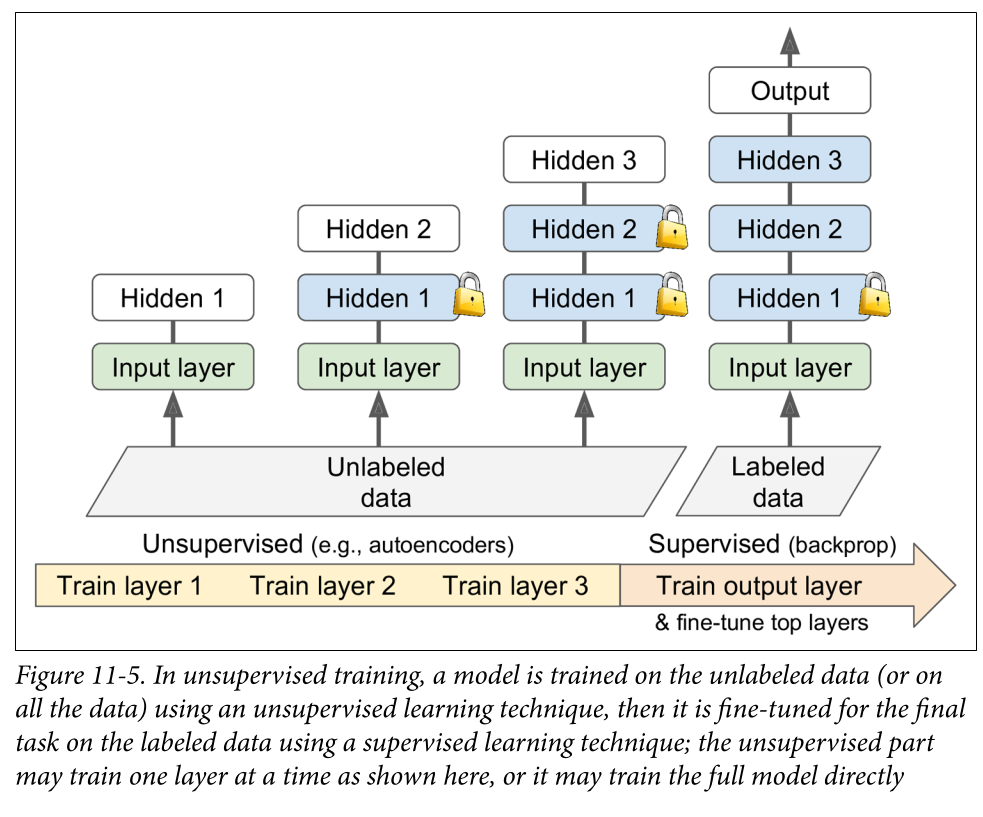

## Pretraining on an Auxiliary Task

If you don't have enough labeled data, you can train a model on a task that is similar to the one you are trying to do, and reuse the first few layer of that task on your actual task. 

For example, if you want to train a classifier that can recognize faces, but you don't have enough images of each person to get a good performance, you can just collect a large number of images of random people on the internet and train a classifier that can, for example, tell if two different pictures feature the same person or not. After you train such a model, you can reuse the first few layers of this model on your original task, which is to recognize the faces of a few individuals.  

## Faster Optimizers

### Momentum Optimization

The momentum algorithm in machine learning is similar to the momentum of objects falling down a hill. The idea is to keep the gradient update going by utilizing the newly calculated gradient and the previous gradient to update the weights. 

The equation for updating the weights without momentum is: <br>
$\theta_{new} = \theta_{old} - \eta*\nabla_{\theta_{old}}J(\theta_{old})$

The equation for updating the weights with momentum is: <br>
$m_{new} = \beta*m_{old} - \eta*\nabla_{\theta_{old}}J(\theta_{old})$ <br>
$\theta_{new} = \theta_{old} + m_{new}$

The algorithm uses the $\beta$ hyperparamter as a friction mechanism to prevent the momentum from growing too large. In this situation, the gradient is used to gain _acceleration_ rather than for _speed_. 

__Notes:__ 

* The value for $\beta$ should range between 0 and 1, where 0 means high friction, and 1 means no friction.
* Due to the momentum, the optimizer may overshoot the minimum and then come back, overshoot, and comes back, until it stabilizes at the minimum, this is why we need some friction term to cancel these oscillations. 

In [3]:
#implementing momentum in keras!
optimizer = keras.optimizers.SGD(learning_rate = 0.01, momentum = 0.9)

### Nestrov Accelerated Gradient

A small tweak to the vanilla momentum optimizer is to calculate the cost function at a place that is slightly ahead of the local position (Instead of calculating at the position $\theta$, we calculate the position $\theta + \beta*m$). 

The equation for nestrov momentum: <br>
$m_{new} = \beta*m_{old} - \eta*\nabla_{\theta_{old}}J(\theta_{old} + \beta*m)$ <br>
$\theta_{new} = \theta_{old} + m$



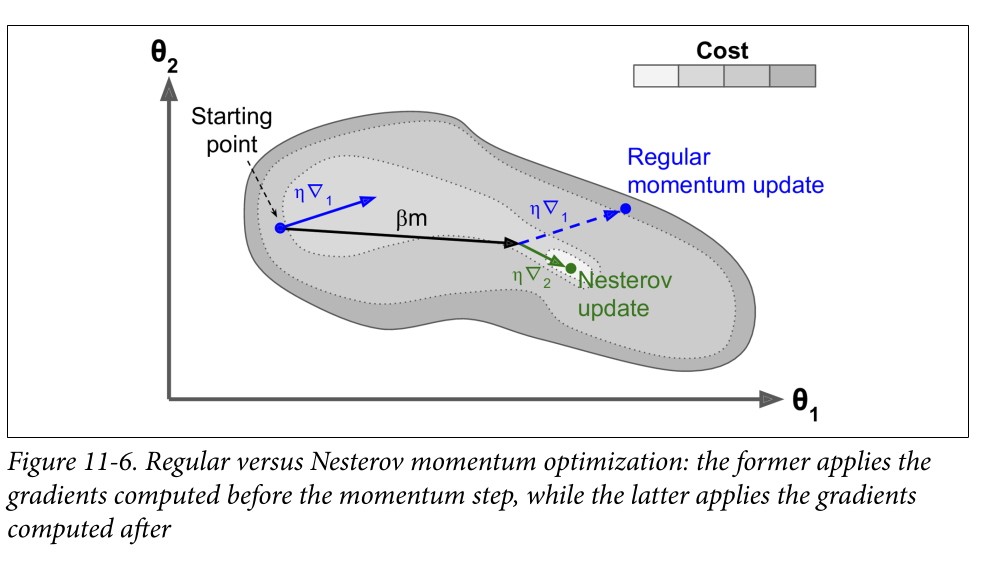

In [6]:
#implementing nesterov momentum in keras!
optimizer = keras.optimizers.SGD(learning_rate = 0.01, momentum = 0.9, nesterov = True)

### AdaGrad

Sometimes, training starts going down a steep slope that doesn't necessarily point in the direction of the global minimum. After a while, it gradually starts pointing towards the global minimum, but it would be nice if it was possible to guide the training towards the bottom of the valley from the beginning. AdaGrad tries to do that by scaling down the gradient vector along the steepest dimensions. 

$s_{new} = s + \nabla_{\theta_{old}}J(\theta_{old}) @ \nabla_{old}J(\theta_{old})$ <br>
$\theta_{new} = \theta_{old} - \eta*\nabla_{\theta_{old}}J(\theta_{old}) / \sqrt{s_{new} + \epsilon}$

s = scaling vector. <br>
$@$ = element-wise multiplication. <br>
$/$ = element-wise division. <br>

The $s$ vector contains the squares of the gradients in each dimension, which is then used to rescale the gradient so that steep dimensions get smaller. 

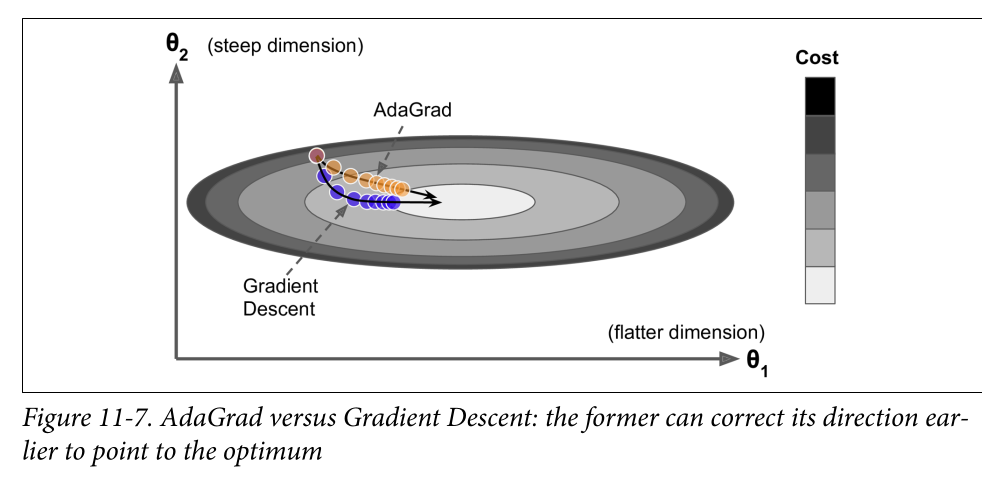

AdaGrad effectively decays the learning rate, but it does so faster for steep dimensions than for dimensions with gentler slopes. 

__Note:__ AdaGrad can work well for small and simple problems, but it is not a good option for complex ones because the training could stop way before reaching a global minimum. 

In [4]:
#adagrad in keras!
optimizer = keras.optimizers.Adagrad()

### RMSProp

RMSProp fixes the issues with Adagrad by only accumulating the gradients from the most recent iterations as opposed to all the gradients since the beginning of training. It does this by using an exponential decay term in the first step:

$s_{new} = \beta*s_{old} + (1 - \beta)\nabla_{\theta_{old}}J(\theta_{old}) @ \nabla_{\theta_{old}}J(\theta_{old})$ <br>
$\theta_{new} = \theta_{old} - \eta*\nabla_{\theta_{old}}J(\theta_{old})/\sqrt{s_{new} + \epsilon}$

The decay rate is $\beta$, which is typically set to 0.9. 

In [5]:
#RMSprop in keras!
#rho = decay rate.
optimizer = keras.optimizers.RMSprop(learning_rate = 0.001, rho = 0.9)

### Adam and Nadam optimization

Adam (Adaptive momentum estimation) combines the ideas from RMSprop and momentum into a single optimizer as follows:

1. $m <== \beta_{1}*m - (1-\beta_{1})\nabla_{\theta}J(\theta)$
2. $s <== \beta_{2}*s + (1-\beta_{2})*\nabla_{\theta}J(\theta)@\nabla_{\theta}J(\theta)$
3. $\hat{m} <== \frac{m}{1-\beta_{1}^t}$
4. $\hat{s} <== \frac{s}{1-\beta_{2}^t}$
5. $\theta <== \theta + \eta*\hat{m}/\sqrt{\hat{s}+\epsilon}$


t = iteration number (starting at 1).

Check the following videos from the deep learning specialization:<br>
Moving averages: <br>
https://www.youtube.com/watch?v=lAq96T8FkTw <br>
Bias correction: <br>
https://www.youtube.com/watch?v=lWzo8CajF5s <br>
Adam: <br>
https://www.youtube.com/watch?v=JXQT_vxqwIs


In [7]:
#Adam in keras!
optimizer = keras.optimizers.Adam(learning_rate = 0.001, beta_1 = 0.9, beta_2 = 0.999)

There are other optimizers that you can look into such as:

* AdaMax, which is a variant of Adam. Adam uses the l2 norm to normalize the RMSprop portion of the calculation (step 2 in the equations for Adam), but AdaMax uses the l_infinity, which is a fancy way of saying the max (specifically, it calculates $s <== max(\beta_{2}s, \nabla_{\theta}J(\theta))$). It also drops step 4 and in step 5, it divides by s instead of the square root (because s is now the l_infinity).

* Nadam, which is simply Adam with the Nesterov trick. 

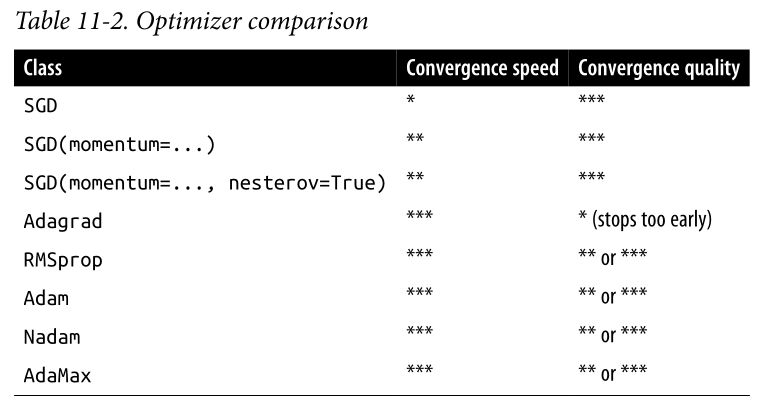

## Learning Rate Scheduling

Choosing a proper learning rate is important for obtaining an optimal solution. If you set it too high, the model ends up diverging. If you set it too low, the model converges to the solution, but it takes too long to reach it. 

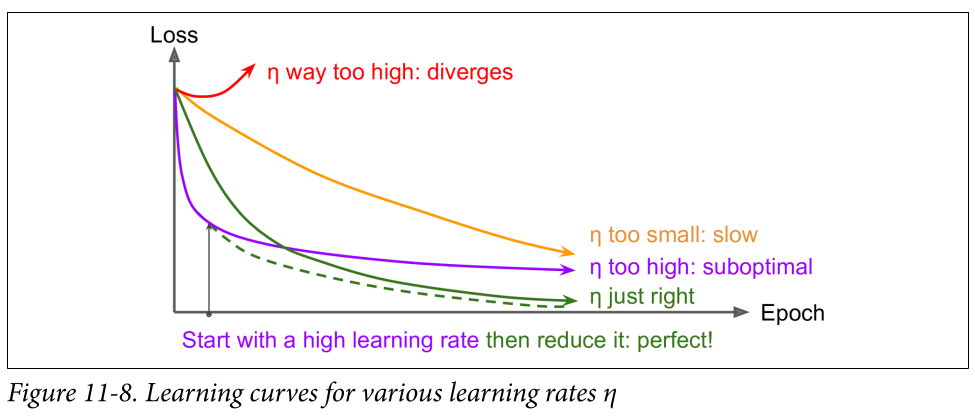

A solution to the problem is illustrated in the above figure. You can set the learning rate to a high value, and after the model stops making progress, you reduce it to get further progress!

The idea is that we decrease or increase the learning rate according to a _learning schedule_. 

There are different types of learning schedules, the most common ones are:

1. Power scheduling: $\eta(t) = \eta_{0} / (1 + t/s)^c$ set the learning rate as a function of the iteration number.
    $\eta_{0} = $ the initial learning rate. <br>
    $c$ = the power (typically set to 1). <br>
    $s$ = the number of steps. <br>
    After s steps, the learning rate is down to $\eta_{0}/2$, after s more steps, it is down to $\eta_{0}/3$, and so on.
2. Exponential scheduling: $\eta(t) = \eta_{0} * 0.1^{t/s}$. <br>
Such an equation drops the learning rate by a factor of 10 every s number of steps. Exponential scheduling is much more aggressive than power scheduling.  
3. Piecewise constant scheduling: Use a constant learning rate for a number of epochs (from epoch 0 to 5, for example), then reduce it for another number of epochs, and so on.
4. Performance scheduling: Measure the validation error every N steps (just like for early stopping), and reduce the learning rate by a factor of $\lambda$ when the error rate stops dropping.
5. 1 cycle scheduling: start with an initial learning rate $\eta_{0}$ and increase it to $\eta_{1}$ linearly halfway through the training. Then decrease the learning rate (still linearly) in the second half of the training. The last few epochs should use a learning rate that is several orders of magnitude smaller than the initial one.  

Implementing schedulers in keras:

In [9]:
def exponential_decay_function(epoch, lr0 = 0.01, s = 20):
    return lr0 * 0.1 * (epoch/s)

In [10]:
learning_scheduler = keras.callbacks.LearningRateScheduler(exponential_decay_function)

In [11]:
#using it on a model
#history = model.fit(X_train, y_train, [...], callbacks = [learning_scheduler])

The exponential_decay_function can also take a second argument that is the current learning rate, which enables you to calculate the next learning rate based on the previous one.

In [22]:
def exponential_decay_function2(epoch, learning_rate):
    return learning_rate / (epoch + 1)

In [23]:
learning_scheduler2 = keras.callbacks.LearningRateScheduler(exponential_decay_function2)

In [24]:
#random example
import numpy as np

model = keras.models.Sequential([
    keras.layers.Input(shape = (100,)),
    keras.layers.Dense(10, activation = 'sigmoid')
])
model.compile(keras.optimizers.SGD(), loss = 'mse')

model.fit(
    np.random.rand(100, 100), 
    np.random.rand(100, 10),
    epochs = 15,
    callbacks = [learning_scheduler2]
)


Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 985us/step - loss: 0.0965 - learning_rate: 0.0100
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 780us/step - loss: 0.0965 - learning_rate: 0.0050
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 857us/step - loss: 0.0953 - learning_rate: 0.0017
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 772us/step - loss: 0.0975 - learning_rate: 4.1667e-04
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 716us/step - loss: 0.0972 - learning_rate: 8.3333e-05
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 757us/step - loss: 0.0966 - learning_rate: 1.3889e-05
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 893us/step - loss: 0.0954 - learning_rate: 1.9841e-06
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 700us/step - loss: 0.0959 - learning_rate: 2.4802e-07
Epoch 9/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 791us/step - loss: 0.0964 - learning_rate: 2.7557e-08
Epoch 10/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 848us/step - loss: 0.0959 - learning_rate: 2.7557e-09
Epoch 11/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 793us/step - loss: 0.0966 - learning_rate

In [25]:
#Performance scheduling:
performance_scheduler = keras.callbacks.ReduceLROnPlateau(factor = 0.5, patience = 5)


You can also use the keras.optimizers.schedules class to define a schedule that updates at each step instead of at each epoch as follows:

In [26]:
training_data_length = 100
s = 20 * training_data_length // 32 #number of steps in 20 epochs(batch size = 32)
learning_rate = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.1,
    decay_steps = s,
    decay_rate = 0.1
)

## Avoiding Overfitting Through Regularization

### l1 and l2 Regularization

You can use l2 regularization to constrain the model by putting a penalty on how large the weights get. l1 regularization does the same, but it usually produces sparse models (much of the weights are set to 0).

__Note:__ l1 norm is simply the sum of the absolute values of the weights, while the l2 norm is the square root of the sum of the squares of the weights. 

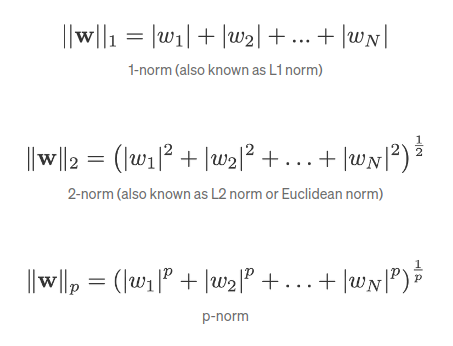

In [27]:
#implementing l2 norm in kears!
layer = keras.layers.Dense(
    100,
    activation = 'elu',
    kernel_initializer = 'he_normal',
    kernel_regularizer = keras.regularizers.l2(0.01)
)

In [29]:
#You have the following regularizers available in keras!
keras.regularizers.l1(0.01)
keras.regularizers.l2(0.01)
keras.regularizers.l1_l2(0.01, 0.01)

You typically apply the same regularization to all the layers in your model. This means that you can write the code more efficiently either by using loops, or by doing the following:

In [32]:
#functools.partial allows you to create a thing wrapper
#for any callable, with default argument values!
from functools import partial 

RegularizedDense = partial(
    keras.layers.Dense, 
    activation = 'elu',
    kernel_initializer = 'he_normal',
    kernel_regularizer = keras.regularizers.l2(0.01)
)

model = keras.models.Sequential([
    keras.layers.Input((28, 28)),
    keras.layers.Flatten(),
    RegularizedDense(300),
    RegularizedDense(100),
    RegularizedDense(10, activation = 'softmax', kernel_initializer = 'glorot_uniform')
])

### Dropout

Dropout does the regularization by dropping a number of neurons (setting their outputs to zero and not updating them) each time it calculates the weights. Each neuron has a change of p, which is called the dropout rate, or being dropped. For RNNs, the dropout rate is around 30%, while for CNNs it is around 40 - 50%. 

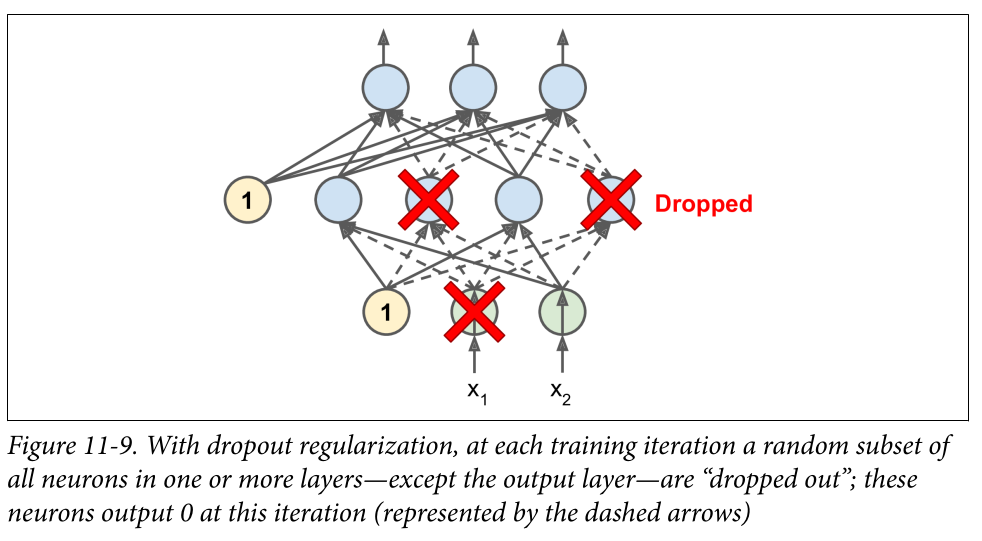

There is a problem that rises after training finishes. Suppose that the dropout rate is 50%. This means that each neuron is trained on half the inputs that it receives, but during testing, it will see all the inputs at once, which will make it receive double the amount of signal during testing. To solve this issue, we can either divide each neuron's output by the keep probability (1-dropout rate), or multiply the weights of the neuron by the keep probability after training. 

In [20]:
#Dropout in keras!
model = keras.models.Sequential([
    keras.layers.Input(shape = (28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(300, activation = 'elu', kernel_initializer='he_normal'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(100, activation = 'elu', kernel_initializer='he_normal'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(10, activation = 'softmax')
])

model.compile(keras.optimizers.Adam(), 'sparse_categorical_crossentropy', metrics = ['accuracy'])


### Monte Carlo (MC) Dropout

Monte Carlo Dropout provides better results than regular Dropout by simply activating Dropout (setting training = True) when calling the prediction function of the model. Then, it calculates the average of a number of predictions per sample to get the better prediction result. 

The following code illustrates this:

In [21]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

In [22]:
X_train_scaled = X_train/255.0
X_test_scaled = X_test/255.0

In [23]:
model.fit(
    X_train_scaled, 
    y_train,
    batch_size = 32,
    epochs = 30,
    validation_split = 0.2
)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7350 - loss: 0.7408 - val_accuracy: 0.8387 - val_loss: 0.4410
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8264 - loss: 0.4666 - val_accuracy: 0.8407 - val_loss: 0.4208
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8375 - loss: 0.4357 - val_accuracy: 0.8507 - val_loss: 0.3978
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8438 - loss: 0.4127 - val_accuracy: 0.8650 - val_loss: 0.3571
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8499 - loss: 0.3968 - val_accuracy: 0.8689 - val_loss: 0.3483
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8565 - loss: 0.3804 - val_accuracy: 0.8747 - val_loss: 0.3463
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8635 - loss: 0.3685 - val_accuracy: 0.8760 - val_loss: 0.3373
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8635 - loss: 0.3614 - 

In [24]:
import numpy as np
#Create an array of 100 predictions to average it later
y_probas = np.stack([model(X_test_scaled, training = True)
                     for sample in range(100)])

#average the predictions to get the final result!
y_proba = y_probas.mean(axis = 0)

In [31]:
from sklearn.metrics import accuracy_score
#accuracy without monte carlo
accuracy_score(y_test, np.argmax(model.predict(X_test_scaled), axis = -1))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 601us/step


0.8894

In [33]:
accuracy_score(y_test, np.argmax(y_proba, axis = -1))

0.8896

As you can see, the accuracy when using the monte carlo method is slightly higher than when not using it!

If you model has some layers that behave differently during training (such as BatchNormalization), you should replace the regular dropout layer with the following one:

In [35]:
class MCDropout(keras.layers.Dropout):
    def call(self, inputs):
        return super().call(inputs, training = True)

In [37]:
model = keras.models.Sequential([
    keras.layers.Input(shape = (28, 28)),
    keras.layers.Flatten(),
    MCDropout(0.2),
    keras.layers.Dense(300, activation = 'elu', kernel_initializer='he_normal'),
    MCDropout(0.2),
    keras.layers.Dense(100, activation = 'elu', kernel_initializer='he_normal'),
    MCDropout(0.2),
    keras.layers.Dense(10, activation = 'softmax')
])

model.compile(keras.optimizers.Adam(), 'sparse_categorical_crossentropy', metrics = ['accuracy'])


In [38]:
model.fit(X_train_scaled, y_train, epochs = 30)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7475 - loss: 0.7116
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8270 - loss: 0.4687
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8450 - loss: 0.4196
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8503 - loss: 0.4028
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8587 - loss: 0.3773
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8588 - loss: 0.3769
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8668 - loss: 0.3585
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8657 - loss: 0.3503
Epoch 9/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8707 - loss: 0.3440
Epoch 10/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8748 - loss: 0.3337
Epoch 11/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8780 - loss: 0.3262
Epoch 12/30
1875/1875 ━━━━━━━━

In [41]:
y_probas = np.stack([model(X_test_scaled) for i in range(100)])

y_proba = y_probas.mean(axis = 0)

In [42]:
accuracy_score(y_test, np.argmax(y_proba, axis = -1))

0.8905

Additionally, if you have a pretrained model that is built with regular dropout, you should build a new model built with MCDropout that is identical to the original one, and copy the weights on it from the original one!

### Max-Norm Regularization

Max-Norm regularization works by limiting the incoming weights to each neuron to a values that is less than or equal to r, which is a hyperparameter. 

$w <= w * r / \begin{Vmatrix}w\end{Vmatrix}_2$

$\begin{Vmatrix} . \end{Vmatrix}_2 = l2\ norm$

In [51]:
#applying max_norm regularization in keras!
keras.layers.Dense(
    100,
    activation = 'elu',
    kernel_initializer='he_normal',
    kernel_constraint=keras.constraints.max_norm(1.0)
)

<Dense name=dense_20, built=False>

## Summary and Practical Guidelines

Default values for DNN configuration (can be changed if you want to!).

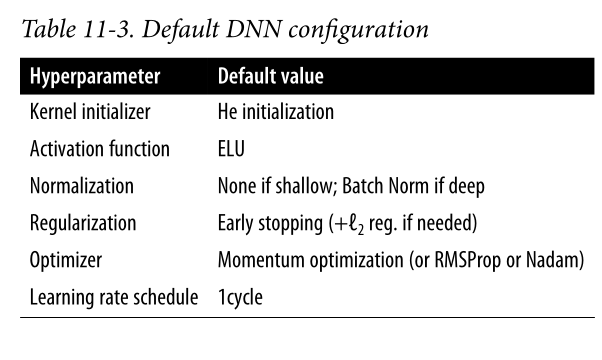

If the neural network is simple, it can self-normalize, and you should use the following configuration:

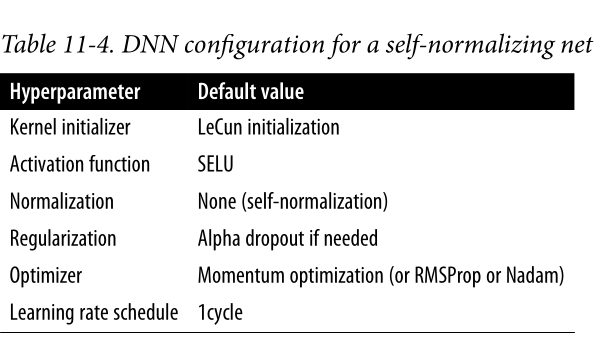

Don't forget to normalize the input features!

Try to also reuse layers from models that solve similar problems to yours, or try to pretrain your model on a similar task!

__Notes:__
* If you need a sparse model, you can use l1 regularization (and zero out the tiny weights after training). If you need an even sparser model, you can use the tensorflow Model Optimization Toolkit. This will break self-normalization, so you should use the default configuration.
* If you want a low-latency model, you should use fewer layers, fold the Batch Normalization layers into the previous layers, and possibly use a faster activation function such as leaky ReLU or just ReLU. Additionally, use TFLite. 
* If you are building a risk-sensitive application, or inference latency is not very important in your application, you can use MC Dropout to boost the performance and get more reliable probability estimates. 